# Code de Correction MAR par rapport a v4 SNOW-CCI puis tendance mais avec SQM non satisfaisant sur le long terme

1.On commence avec la correction de MAR de maniere mensuelle et avec un Delta qunatile mapping

2.Creation de tendance MAR de la hauteur ligne de neige sur l'ensemble du domaine temporel dans ce code cette partie n'est pas la plus interrressante

Dans ce notebook on utilse une version Gap-Filled de la V4 SNOW-CCI ou l'on a une disponibilite complete en donnees. Ainsi que MAR  force par la reanalyse ERA5, cesst le cas pour les 2 autres notebook de correction de ce stage.

## IMPORTANT

#### Une chose a savoir pour la periode de calibration il faut ouvrir sur 2016-2019 pour faire la suite avec la cross validation , mais si lobjectif et daller voir la partie ligne de neige (2) alors il faut ouvrir sur 2016 2021 et ne pas faire tourner les lignes de verifications (donc sarreter apres la definiton des fonctions et la case de leur application) et repartir a la partie 2 

In [1]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import pandas as pd
import sys
import os 
import calendar
from scipy.interpolate import interp1d
import scipy.stats as stats
sys.path.append('/home/mougina/mesnotebooks/utils')
from config import ds_grid, alps_ice, lon, lat, H, alps, get_season 

In [2]:
## topo v4 
lat1, lat2, lon1, lon2 = 43, 48, 5, 17
ds_topo = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/mougina/GMTED2010_15n015_0050deg.nc').rename(
    {'latitude': 'lat', 'longitude': 'lon'}
)
dsi_topo = ds_topo.sel(lat=slice(lat1, lat2), lon=slice(lon1, lon2))
## grille MAR
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")

Dimensions de la topo Alpes : (2400, 6240)
Rugosité Min : -11.0
Rugosité Max : 4712.0


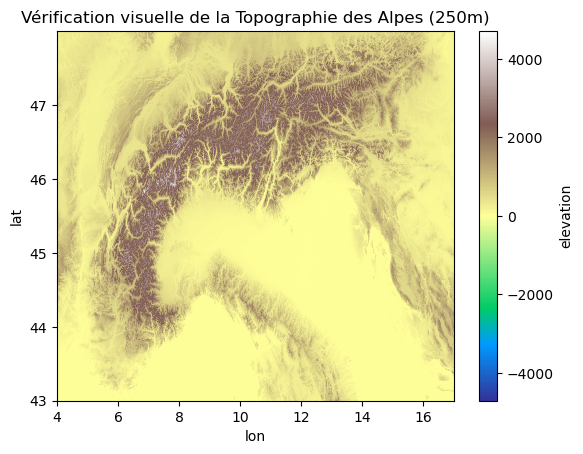

In [5]:
ds_topo_HR = xr.open_dataset("/bettik/PROJECTS/pr-regional-climate/mougina/gmted_topo_alpes_250m.nc")
topo_mondiale_HR = ds_topo_HR['elevation']
lon1, lon2, lat1, lat2 = 4, 17, 43, 48
vrai_topo_alpes_HR = topo_mondiale_HR.sel(
    lon=slice(min(lon1, lon2), max(lon1, lon2)), 
    lat=slice(max(lat1, lat2), min(lat1, lat2))
)
if vrai_topo_alpes_HR.sizes['lat'] == 0:
    vrai_topo_alpes_HR = topo_mondiale_HR.sel(
        lon=slice(min(lon1, lon2), max(lon1, lon2)), 
        lat=slice(min(lat1, lat2), max(lat1, lat2))
    )
print("Dimensions de la topo Alpes :", vrai_topo_alpes_HR.shape)
print("Rugosité Min :", float(vrai_topo_alpes_HR.min()))
print("Rugosité Max :", float(vrai_topo_alpes_HR.max()))

vrai_topo_alpes_HR.plot(cmap='terrain')
plt.title("Vérification visuelle de la Topographie des Alpes (250m)")
plt.show()

In [6]:
facteur_lon = vrai_topo_alpes_HR.shape[1] // ds_grid.LON.shape[1]
facteur_lat = vrai_topo_alpes_HR.shape[0] // ds_grid.LON.shape[0]


sigma_topo_brut = vrai_topo_alpes_HR.coarsen(lon=facteur_lon, lat=facteur_lat, boundary='trim').std()
sigma_topo_aligned = sigma_topo_brut.interp(lon=ds_grid.LON[0, :], lat=ds_grid.LAT[:, 0], method='nearest')
topo_numpy = sigma_topo_aligned.reindex_like(ds_grid, method='nearest').values


In [7]:
file_v2 = '/home/mougina/mes_analyses_neige/Alpine_snow.nc'
ds_v2 = xr.open_dataset(file_v2)

scfg_raw = ds_v2['scfg_interp'].where((ds_v2['scfg_interp'] >= 0) & (ds_v2['scfg_interp'] <= 100))

is_water = ds_v2['mask_water'].fillna(0) == 210
is_ice = ds_v2['mask_ice'].fillna(0) == 215

In [8]:
#base pour la formule de NY07 et LA23

z0g = 0.01         
rho_new = 50.0     ## les donnees so nt celle utilise dans l'article de Lalande et al. 2023
m = 1.0
beta = 3*10**-6
n = 3.0



In [9]:
def get_seasonal_mean(data, season_suffix, years):
    liste = []
    for yr in years:
        target = f"{yr}_{season_suffix}"
        s = data.where(data.season == target).mean(dim='time')
        liste.append(s)
    return xr.concat(liste, dim='year').mean(dim='year')

In [10]:
### fonction calcul du rho moyen 
def calc_rho_mean(ds_rho, SD):
    levels_da = xr.DataArray(
        [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 3.0, 5.0, 10.0, 15.0],
        coords=[ds_rho['outlay']], dims=['outlay']
    )
    
    mask = xr.concat([
        xr.ones_like(ds_rho['RO1'].isel(outlay=[0])),
        (ds_rho['RO1'].diff('outlay') != 0)
    ], dim='outlay')

    # Poids corrigé : le dernier nœud actif s'arrête à SD et non au niveau suivant
    levels_next = levels_da.shift(outlay=-1, fill_value=15.0)
    dz_corrige  = (np.minimum(levels_next, SD) - levels_da.shift(outlay=1, fill_value=0.0)) / 2
    dz_corrige  = dz_corrige.clip(min=0)

    return (ds_rho['RO1'].where(mask)
            .weighted(dz_corrige.where(mask).fillna(0))
            .mean(dim='outlay'))

### 1ere Partie 

In [11]:
years_train = [2016, 2017, 2018, 2019]
lat1, lat2, lon1, lon2 =  43, 48, 5, 17  # Alpes

In [12]:
list_mar = []
list_v4= []
lon_1d = ds_grid.LON[0, :] 
lat_1d = ds_grid.LAT[:, 0] 
for i, yr in enumerate(years_train):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    topo_numpy = sigma_topo_aligned.fillna(0).values
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    list_mar.append(scf_mar)
    
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs:
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <= 100, np.nan)
    v4_regrid = ds_v['scfg'].interp(
        lon=ds_grid.LON, lat=ds_grid.LAT,
        method="linear", kwargs={'fill_value': np.nan}
    )
    list_v4.append(v4_regrid)

all_mar_train = xr.concat(list_mar, dim='time')
all_v4_train  = xr.concat(list_v4, dim='time')

all_mar_train = all_mar_train.sel(time=all_v4_train.time, method="nearest")
# Masque une seule fois
alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])
all_mar_train = all_mar_train.where(alps_ice_da)

clim_v4 = all_v4_train.groupby('time.month').mean(dim='time')
clim_mar = all_mar_train.groupby('time.month').mean(dim='time')



biais_pixel_mensuel = clim_mar - clim_v4
print("biais shape:", biais_pixel_mensuel.shape)



biais shape: (12, 126, 201)


les fonctions utiles

In [13]:
# correction technique simple quantile
def qdm_calibrer(all_mar_train, all_v4_train, n_quantiles=50):
    alps_ice_da = xr.DataArray(alps_ice, dims=all_mar_train.dims[1:])
    quantiles = np.linspace(0, 1, n_quantiles)
    quantiles_ref = {}
    
    for m in range(1, 13):
        mar_mois = all_mar_train.where(all_mar_train['time.month'] == m, drop=True)
        v4_mois  = all_v4_train.where(all_v4_train['time.month'] == m, drop=True)
        
        if mar_mois.sizes['time'] == 0:
            continue
            
        mar_vals = mar_mois.values
        v4_vals  = v4_mois.values
        alps_mask = alps_ice_da.values
        _, nlat, nlon = mar_vals.shape
        
        q_mar_mois = np.full((n_quantiles, nlat, nlon), np.nan)
        q_v4_mois  = np.full((n_quantiles, nlat, nlon), np.nan)
        freq_v4_mois = np.full((nlat, nlon), np.nan)# Pour stocker la freq des zéros V4
        freq_mar_mois = np.full((nlat, nlon), np.nan)# Pour stocker la freq des zéros MAR
        np.random.seed(42)
        for i in range(nlat):
            for j in range(nlon):
                if not alps_mask[i, j]:
                    continue
                
                mar_px = mar_vals[:, i, j]
                v4_px  = v4_vals[:, i, j]
                
                mar_valid = mar_px[~np.isnan(mar_px)]
                v4_valid  = v4_px[~np.isnan(v4_px)]
                
                if len(mar_valid) < 10 or len(v4_valid) < 10:
                    continue
                
                mar_px_corr = np.where(mar_px == 0,np.random.uniform(0, 1e-5, mar_px.shape),mar_px)

                mar_valid_corr = mar_px_corr[~np.isnan(mar_px_corr)]
                q_mar_mois[:, i, j] = np.quantile(mar_valid_corr, quantiles)
                q_v4_mois[:, i, j]  = np.quantile(v4_valid, quantiles)
                            

                
        quantiles_ref[m] = {'q_mar'   : q_mar_mois,'q_v4'    : q_v4_mois}
        
    return quantiles_ref

def qdm_appliquer(all_mar, quantiles_ref, n_quantiles=50):
    alps_ice_da = xr.DataArray(alps_ice, dims=all_mar.dims[1:])
    quantiles = np.linspace(0, 1, n_quantiles)
    liste_corriges = []
    
    for m in range(1, 13):
        mar_mois = all_mar.where(all_mar['time.month'] == m, drop=True)
        if mar_mois.sizes['time'] == 0:
            continue
            
        q_mar_ref = quantiles_ref[m]['q_mar']
        q_v4_ref  = quantiles_ref[m]['q_v4']
        
        mar_vals  = mar_mois.values
        alps_mask = alps_ice_da.values
        n_jours, nlat, nlon = mar_vals.shape
        mar_corrige = np.full_like(mar_vals, np.nan)
        np.random.seed(42)
        for i in range(nlat):
            for j in range(nlon):
                if not alps_mask[i, j]:
                    continue
                
                mar_px = mar_vals[:, i, j]
                q_mar  = q_mar_ref[:, i, j]
                q_v4   = q_v4_ref[:, i, j]
                if np.isnan(q_mar).any() or np.isnan(q_v4).any():
                    mar_corrige[:, i, j] = mar_px
                    continue

                mar_px_corr = np.where(mar_px == 0,np.random.uniform(0, 1e-5, mar_px.shape),mar_px)

                mar_to_q = interp1d(q_mar, quantiles, bounds_error=False, fill_value=(0, 1))
                q_to_v4  = interp1d(quantiles, q_v4,  bounds_error=False, fill_value=(q_v4[0], q_v4[-1]))
                q_to_mar = interp1d(quantiles, q_mar, bounds_error=False, fill_value=(q_mar[0], q_mar[-1]))
                
                ranks = mar_to_q(mar_px_corr)
                delta = mar_px_corr - q_to_mar(ranks)
                mar_corrige[:, i, j] = q_to_v4(ranks) + delta
                
        mar_corrige_da = xr.DataArray(mar_corrige, coords=mar_mois.coords, dims=mar_mois.dims).clip(0, 100)
        liste_corriges.append(mar_corrige_da)
        
    return xr.concat(liste_corriges, dim='time').sortby('time')

In [14]:
# correction par biais moyen mensuel 
def corriger_biais_pixel(all_mar_train, biais_pixel_mensuel):
    liste_corriges = []
        
    for m in range(1, 13):
        mar_jours = all_mar_train.where(all_mar_train['time.month'] == m, drop=True)
        if mar_jours.sizes['time'] == 0:
            continue
                
        m_prev = 12 if m == 1 else m - 1
        m_next = 1  if m == 12 else m + 1
                
        # ICI : On utilise bien la variable biais_pixel_mensuel (et pas le nom de la fonction !)
        biais_prev = biais_pixel_mensuel.sel(month=m_prev)
        biais_curr = biais_pixel_mensuel.sel(month=m)
        biais_next = biais_pixel_mensuel.sel(month=m_next)
                
        n_jours = mar_jours.sizes['time']
                
        for t in range(n_jours):
            pos = t / (n_jours - 1) if n_jours > 1 else 0.5
            
            if pos < 0.5:
                alpha = pos * 2  
                biais_t = (1 - alpha) * biais_prev + alpha * biais_curr
            else:
                alpha = (pos - 0.5) * 2  
                biais_t = (1 - alpha) * biais_curr + alpha * biais_next
                        
            jour_corrige = (mar_jours.isel(time=t) - biais_t).clip(0, 100)
            liste_corriges.append(jour_corrige)
        
    return xr.concat(liste_corriges, dim='time').sortby('time')

all_mar_corrige= corriger_biais_pixel(all_mar_train, biais_pixel_mensuel)

In [15]:
ds_quantiles_ref = qdm_calibrer(all_mar_train, all_v4_train)
all_mar_corr_train = corriger_biais_pixel(all_mar_train, biais_pixel_mensuel)
all_mar_qdm_train = qdm_appliquer(all_mar_train, ds_quantiles_ref)

### Verification de l'entrainement de notre correction MAR 2016-2019

In [16]:

alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])

v4_numpy      = all_v4_train.where(alps_ice_da).values.ravel()
mar_numpy     = all_mar_train.where(alps_ice_da).values.ravel()
qdm_px_numpy     = all_mar_qdm_train.where(alps_ice_da).values.ravel()
corrige_numpy = all_mar_corr_train.where(alps_ice_da).values.ravel()

# Enlever les NaN
mask_valid = (~np.isnan(v4_numpy) & ~np.isnan(mar_numpy)& ~np.isnan(corrige_numpy) & ~np.isnan(qdm_px_numpy))

bias_brut    = np.nanmean(mar_numpy[mask_valid] - v4_numpy[mask_valid])
bias_corrige = np.nanmean(corrige_numpy[mask_valid] - v4_numpy[mask_valid])
bias_qdm_px     = np.nanmean(qdm_px_numpy[mask_valid] - v4_numpy[mask_valid])

print(f"Biais Moyen sans correction : {bias_brut:.3f} %")
print(f"Biais Moyen correction additive : {bias_corrige:.3f} %")
print(f"Biais Moyen QDM pixel par pixel : {bias_qdm_px:.3f} %")

Biais Moyen sans correction : -6.106 %
Biais Moyen correction additive : -0.740 %
Biais Moyen QDM pixel par pixel : 0.056 %


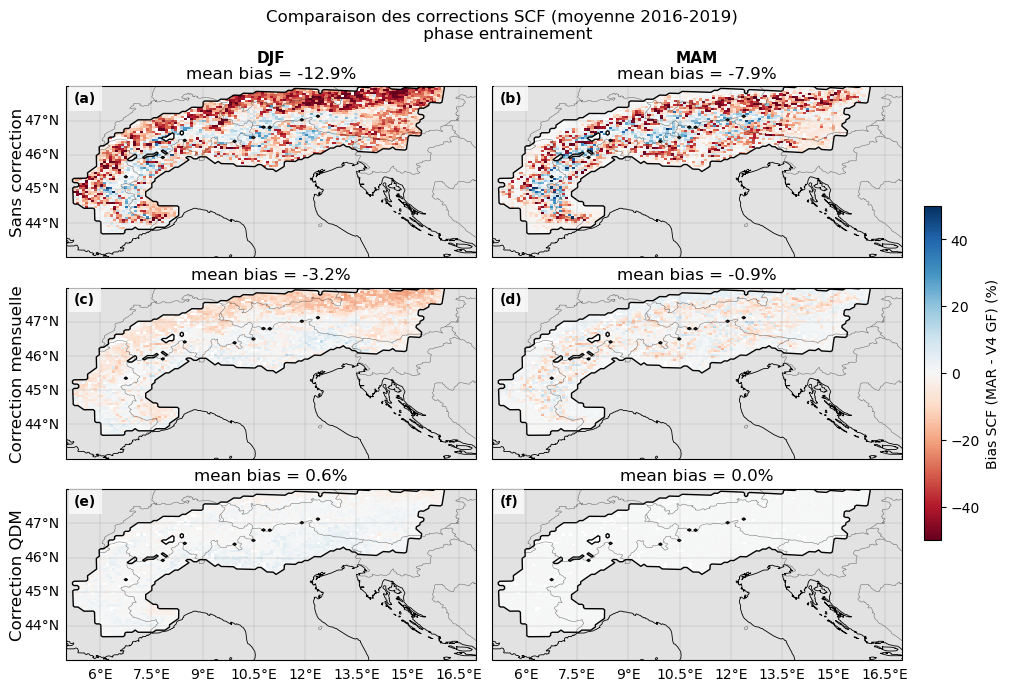

In [17]:
time_pd_v4 = all_v4_train.time.to_index()
season_labels = [get_season(t) for t in time_pd_v4]
all_mar= all_mar_train.assign_coords(season=('time', season_labels))
all_mar_qdm_px= all_mar_qdm_train.assign_coords(season=('time', season_labels))
all_mar_corrige= all_mar_corr_train.assign_coords(season=('time', season_labels))
all_v4 = all_v4_train.assign_coords(season=('time', season_labels))



winter_brut   = get_seasonal_mean(all_mar, 'DJF', years_train)
spring_brut   = get_seasonal_mean(all_mar, 'MAM', years_train)

winter_corr   = get_seasonal_mean(all_mar_corrige, 'DJF', years_train)
spring_corr   = get_seasonal_mean(all_mar_corrige, 'MAM', years_train)

winter_qm     = get_seasonal_mean(all_mar_qdm_px, 'DJF', years_train)
spring_qm     = get_seasonal_mean(all_mar_qdm_px, 'MAM', years_train)


winter_v4= get_seasonal_mean(all_v4, 'DJF', years_train)
spring_v4 = get_seasonal_mean(all_v4, 'MAM', years_train)


rows = [
    ('Sans correction',      winter_brut  - winter_v4, spring_brut  - spring_v4),
    ('Correction mensuelle', winter_corr  - winter_v4, spring_corr  - spring_v4),
    ('Correction QDM',        winter_qm    - winter_v4, spring_qm    - spring_v4),
]


fig, axs = plt.subplots(3, 2, figsize=(10, 6.8),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)
grey_mask = np.where(alps, np.nan, 0.2)

for i, (titre, diff_w, diff_s) in enumerate(rows):
    for j, (ax, diff, season_name) in enumerate([
        (axs[i,0], diff_w.where(alps_ice==True), 'DJF'),
        (axs[i,1], diff_s.where(alps_ice==True), 'MAM')
    ]):
        idx = i * 2 + j
        lettre = f"({chr(97 + idx)})" 
        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())
        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, diff,
                           cmap='RdBu', vmin=-50, vmax=50,
                           transform=ccrs.PlateCarree())
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0)
        if i == 0:
            ax.text(0.5, 1.12, f"{season_name}", transform=ax.transAxes,
                    fontsize=11, ha='center', va='bottom', fontweight='bold')

        if j == 0:
            ax.text(-0.1, 0.5, titre, transform=ax.transAxes,
                    fontsize=12, ha='right', va='center', rotation=90)
        biais_mean = float(np.nanmean(diff))
        ax.set_title(f"mean bias = {biais_mean:.1f}%", fontsize=12)
        ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top',
                    bbox=dict(fc='white', ec='none', alpha=0.7))
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.bottom_labels = False
        if j == 0:
            gl.left_labels = True
        if i == 2:
            gl.bottom_labels = True
    
cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.02, shrink=0.6)
cbar.set_label('Bias SCF (MAR - V4 GF) (%)', fontsize=10)
plt.suptitle('Comparaison des corrections SCF (moyenne 2016-2019) \n phase entrainement', size=12)
#plt.savefig('/home/mougina/mes_analyses/correction_MAR/comparaison_corrections_SCF_train.png', dpi=100)
plt.show()

### Phase de test sur les annees restante 2020-2021 **PLOT QUE SI TRAIN A TOURNER SUR 2016-2019 ET PAS 2016-2021**

In [18]:
years_test = [2020,2021]
lat1, lat2, lon1, lon2 =  43, 48, 5, 17  # Alpes

In [19]:

list_mar = []
list_v4  = []

for i, yr in enumerate(years_test):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    topo_numpy = sigma_topo_aligned.fillna(0).values
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + \
                   (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    list_mar.append(scf_mar)
    
    ds_v_raw = xr.open_dataset(
        f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc",
        decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs:
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <= 100, np.nan)
    v4_regrid = ds_v['scfg'].interp(
        lon=ds_grid.LON, lat=ds_grid.LAT,
        method="linear", kwargs={'fill_value': np.nan}
    )
    list_v4.append(v4_regrid)

all_mar_test = xr.concat(list_mar, dim='time')
all_v4_test  = xr.concat(list_v4,  dim='time')
all_mar_test = all_mar_test.sel(time=all_v4_test.time, method="nearest")
alps_ice_da  = xr.DataArray(alps_ice, dims=['y', 'x'])
all_mar_test = all_mar_test.where(alps_ice_da)


all_mar_corr_test = corriger_biais_pixel(all_mar_test, biais_pixel_mensuel)
all_mar_qdm_test = qdm_appliquer(all_mar_test, ds_quantiles_ref)

print("Test chargé — MAR shape:", all_mar_test.shape)
print("Biais utilisé (entraînement):", biais_pixel_mensuel.shape)



Test chargé — MAR shape: (609, 126, 201)
Biais utilisé (entraînement): (12, 126, 201)


In [20]:


alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])

v4_test     = all_v4_test.where(alps_ice_da).values.ravel()
mar_test     = all_mar_test.where(alps_ice_da).values.ravel()
qdm_px_test   = all_mar_qdm_test.where(alps_ice_da).values.ravel()
corrige_test = all_mar_corr_test.where(alps_ice_da).values.ravel()

# Enlever les NaN
mask_valid = (~np.isnan(v4_test) & ~np.isnan(mar_test)& ~np.isnan(corrige_test) & ~np.isnan(qdm_px_test))

bias_brut_test   = np.nanmean(mar_test[mask_valid] - v4_test[mask_valid])
bias_corrige_test = np.nanmean(corrige_test[mask_valid] - v4_test[mask_valid])
bias_qdm_px_test    = np.nanmean(qdm_px_test[mask_valid] - v4_test[mask_valid])

print(f"Biais Moyen sans correction : {bias_brut_test:.3f} %")
print(f"Biais Moyen correction additive : {bias_corrige_test:.3f} %")
print(f"Biais Moyen QDM pixel par pixel : {bias_qdm_px_test:.3f} %")

Biais Moyen sans correction : -5.661 %
Biais Moyen correction additive : -0.343 %
Biais Moyen QDM pixel par pixel : 0.373 %


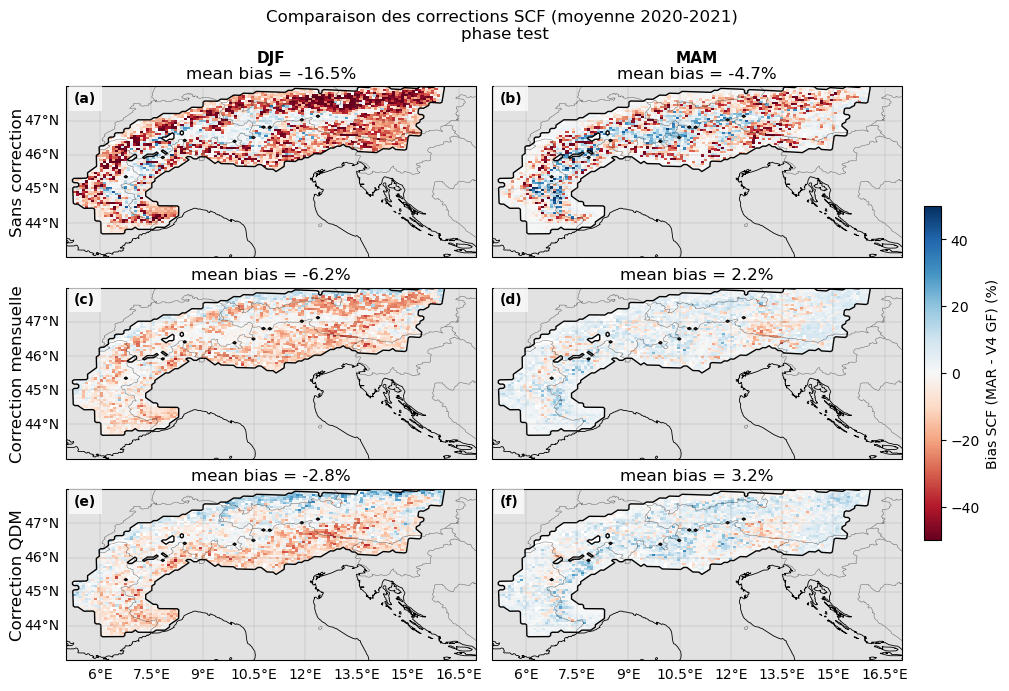

In [21]:
time_pd_v4 = all_v4_test.time.to_index()
season_labels = [get_season(t) for t in time_pd_v4]
all_mar_test= all_mar_test.assign_coords(season=('time', season_labels))
all_mar_qdm_px_test= all_mar_qdm_test.assign_coords(season=('time', season_labels))
all_mar_corrige_test= all_mar_corr_test.assign_coords(season=('time', season_labels))
all_v4_test= all_v4_test.assign_coords(season=('time', season_labels))

winter_brut_test   = get_seasonal_mean(all_mar_test, 'DJF', years_test)
spring_brut_test   = get_seasonal_mean(all_mar_test, 'MAM', years_test)

winter_corr_test   = get_seasonal_mean(all_mar_corrige_test, 'DJF', years_test)
spring_corr_test   = get_seasonal_mean(all_mar_corrige_test, 'MAM', years_test)

winter_qm_test     = get_seasonal_mean(all_mar_qdm_px_test, 'DJF', years_test)
spring_qm_test    = get_seasonal_mean(all_mar_qdm_px_test, 'MAM', years_test)


winter_v4_test= get_seasonal_mean(all_v4_test, 'DJF', years_test)
spring_v4_test = get_seasonal_mean(all_v4_test, 'MAM', years_test)


rows = [
    ('Sans correction',      winter_brut_test  - winter_v4_test, spring_brut_test - spring_v4_test),
    ('Correction mensuelle', winter_corr_test  - winter_v4_test , spring_corr_test  - spring_v4_test),
    ('Correction QDM',        winter_qm_test    - winter_v4_test, spring_qm_test    - spring_v4_test),
]


fig, axs = plt.subplots(3, 2, figsize=(10, 6.8),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)
grey_mask = np.where(alps, np.nan, 0.2)

for i, (titre, diff_w, diff_s) in enumerate(rows):
    for j, (ax, diff, season_name) in enumerate([
        (axs[i,0], diff_w.where(alps_ice==True), 'DJF'),
        (axs[i,1], diff_s.where(alps_ice==True), 'MAM')
    ]):
        idx = i * 2 + j
        lettre = f"({chr(97 + idx)})" 
        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())
        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, diff,
                           cmap='RdBu', vmin=-50, vmax=50,
                           transform=ccrs.PlateCarree())
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0)
        if i == 0:
            ax.text(0.5, 1.12, f"{season_name}", transform=ax.transAxes,
                    fontsize=11, ha='center', va='bottom', fontweight = 'bold')

        if j == 0:
            ax.text(-0.1, 0.5, titre, transform=ax.transAxes,
                    fontsize=12, ha='right', va='center', rotation=90)
        biais_mean = float(np.nanmean(diff))
        ax.set_title(f"mean bias = {biais_mean:.1f}%", fontsize=12)
        ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top',
                    bbox=dict(fc='white', ec='none', alpha=0.7))
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.bottom_labels = False
        if j == 0:
            gl.left_labels = True
        if i == 2:
            gl.bottom_labels = True
    
cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.02, shrink=0.6)
cbar.set_label('Bias SCF (MAR - V4 GF) (%)', fontsize=10)
plt.suptitle('Comparaison des corrections SCF (moyenne 2020-2021) \nphase test', size=12)
#plt.savefig('/home/mougina/mes_analyses/correction_MAR/comparaison_corrections_SCF_test.png', dpi=100)
plt.show()

Synthese des deux Graph de presentation

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


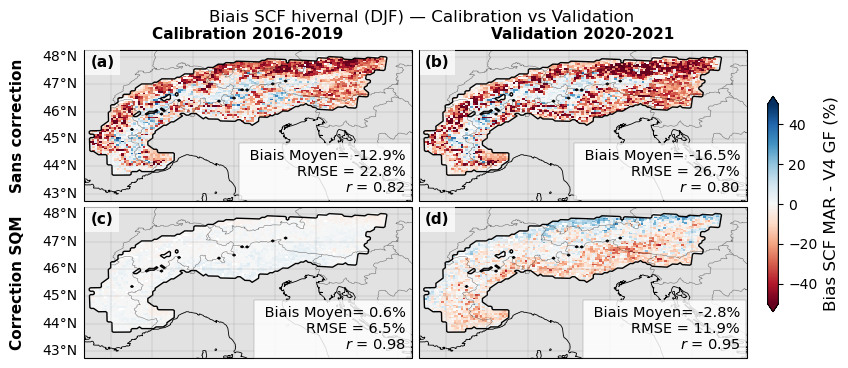

In [22]:
import scipy.stats as stats

fig, axs = plt.subplots(2, 2, figsize=(9, 4),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.02, 'hspace': 0.04})
grey_mask = np.where(alps, np.nan, 0.2)

rows = [
    ('Sans correction',      
     winter_brut   - winter_v4,      # calibration
     winter_brut_test - winter_v4_test),  # test
    ('Correction SQM',        
     winter_qm     - winter_v4,
     winter_qm_test - winter_v4_test),
]

col_titles = ['Calibration 2016-2019', 'Validation 2020-2021']

for i, (titre, diff_calib, diff_test) in enumerate(rows):
    for j, (ax, diff, col_title) in enumerate([
        (axs[i,0], diff_calib.where(alps_ice==True), col_titles[0]),
        (axs[i,1], diff_test.where(alps_ice==True),  col_titles[1])
    ]):
        
        ax.set_adjustable('datalim')
        
        idx = i * 2 + j
        idx = i * 2 + j
        lettre = f"({chr(97 + idx)})"
        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())
        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, diff,
                           cmap='RdBu', vmin=-50, vmax=50,
                           transform=ccrs.PlateCarree())
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0)

        if i == 0:
            ax.text(0.5, 1.05, col_title, transform=ax.transAxes,
                    fontsize=11, ha='center', va='bottom', fontweight='bold')

        if j == 0:
            ax.text(-0.18, 0.5, titre, transform=ax.transAxes,
                    fontsize=11, ha='right', va='center', rotation=90, fontweight='bold',ma='center')
        
        biais_mean = float(np.nanmean(diff))
        ref_complete = winter_v4 if j == 0 else winter_v4_test
        if j == 0:  
            mod_complete = winter_brut if i == 0 else (winter_corr if i == 1 else winter_qm)
        else:     
            mod_complete = winter_brut_test if i == 0 else (winter_corr_test if i == 1 else winter_qm_test)
        v_mod = mod_complete.where(alps_ice==True).values.flatten()
        v_ref = ref_complete.where(alps_ice==True).values.flatten()
        mask_valid = ~np.isnan(v_mod) & ~np.isnan(v_ref)
        rmse = float(np.sqrt(np.mean((v_mod[mask_valid] - v_ref[mask_valid]) ** 2)))
        r_val, _ = stats.pearsonr(v_mod[mask_valid], v_ref[mask_valid])    
        stats_text = f" Biais Moyen= {biais_mean:.1f}%\nRMSE = {rmse:.1f}%\n$r$ = {r_val:.2f}"
        ax.text(0.98, 0.04, stats_text, transform=ax.transAxes,
                fontsize=10.5, ha='right', va='bottom', zorder=5,
                bbox=dict(fc='white', ec='gray', lw=0.3, alpha=0.85))
        ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top',
                bbox=dict(fc='white', ec='none', alpha=0.7))
        
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels    = False
        gl.right_labels  = False
        gl.left_labels   = False
        gl.bottom_labels = False
        if j == 0:
            gl.left_labels = True
        if i == 2:
            gl.bottom_labels = True

fig.subplots_adjust(wspace=0.01, hspace=0.01)

cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.03, shrink=0.7, extend='both', extendfrac=0.04)
cbar.set_label('Bias SCF MAR - V4 GF (%)', fontsize=12)

plt.suptitle('Biais SCF hivernal (DJF) — Calibration vs Validation', size=12, y=0.98)
plt.savefig('/home/mougina/mes_analyses_neige/correction_SQM_cross_test.png', 
            dpi=200, bbox_inches='tight')
plt.show()

# 2 eme Partie

ouverture MAR sur toute la periode 

In [23]:
years = range(1940, 2025)
lat1, lat2, lon1, lon2 =  43, 48, 5, 17  # Alpes

Inversion de la fonction, on retrouve SD apres correction DQM ou mens

fonction ligne de neige

In [14]:

altitude = ds_grid['SH'].values  

def calculer_ligne_neige_journaliere(scf_mar, altitude, alps_ice, seuil=50, n_pixels=10):
    """
    Calcule la ligne de neige selon 3 critères :
    (i)  mean elevation des 10 plus hauts pixels SANS neige (SCF < seuil)
    (ii) mean elevation des 10 plus bas pixels AVEC neige (SCF >= seuil)
    (iii) moyenne de (i) et (ii) → ligne de neige
    """
    alt_flat = altitude[alps_ice]
    n_temps = scf_mar.sizes['time']
    
    critere_1 = np.full(n_temps, np.nan)  
    critere_2 = np.full(n_temps, np.nan)  
    critere_3 = np.full(n_temps, np.nan)   
    for t in range(n_temps):
        jour = scf_mar.isel(time=t).values
        scf_flat = jour[alps_ice]
        
        mask_valid = ~np.isnan(scf_flat)
        scf_v = scf_flat[mask_valid]
        alt_v = alt_flat[mask_valid]
        
        if len(scf_v) < 20:
            continue
        alt_avec_neige = alt_v[scf_v >= seuil]
        alt_sans_neige = alt_v[scf_v < seuil]
        
        if len(alt_avec_neige) < n_pixels or len(alt_sans_neige) < n_pixels:
            continue
        critere_1[t] = np.mean(np.sort(alt_sans_neige)[-n_pixels:])
        critere_2[t] = np.mean(np.sort(alt_avec_neige)[:n_pixels])

        critere_3[t] = (critere_1[t] + critere_2[t]) / 2
    return (
        xr.DataArray(critere_1, coords=[scf_mar.time], dims=['time']),
        xr.DataArray(critere_2, coords=[scf_mar.time], dims=['time']),
        xr.DataArray(critere_3, coords=[scf_mar.time], dims=['time'])
    )

In [15]:


list_scf_annuel = []
list_ln1_brut, list_ln2_brut, list_ln3_brut = [], [], []
list_ln1_qdm,  list_ln2_qdm,  list_ln3_qdm  = [], [], []
list_ln1_corr, list_ln2_corr, list_ln3_corr = [], [], []

altitude = ds_grid['SH'].values  

for yr in years: 
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    rho_snow = ds_rho['RO1'].isel(outlay=0)
    SD = ds_m['ZN3']
    topo_numpy = sigma_topo_aligned.fillna(0).values
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + \
                   (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])
    scf_mar = scf_mar.where(alps_ice_da)

    scf_qdm  = qdm_appliquer(scf_mar, ds_quantiles_ref)
    scf_corr = corriger_biais_pixel(scf_mar, biais_pixel_mensuel)
    
    scd_mar_jours  = xr.where(scf_mar > 50, 1, 0).sum(dim='time')
    scd_qdm_jours  = xr.where(scf_qdm > 50, 1, 0).sum(dim='time')
    scd_corr_jours = xr.where(scf_corr > 50, 1, 0).sum(dim='time')
    
    
            ###scf annuel
    list_scf_annuel.append({
    'year'   : yr,
    'brut'   : float(np.nanmean(scf_mar.values)),
    'qdm'    : float(np.nanmean(scf_qdm.values)),
    'mensuel': float(np.nanmean(scf_corr.values)) })
    list_scf_annuel[-1].update({
        'scd_brut':    float(scd_mar_jours.where(alps_ice_da).mean()),
        'scd_qdm':     float(scd_qdm_jours.where(alps_ice_da).mean()),
        'scd_mensuel': float(scd_corr_jours.where(alps_ice_da).mean())
    })
        ### ligne de neige
    ln1_brut, ln2_brut, ln3_brut = calculer_ligne_neige_journaliere(scf_mar,  altitude, alps_ice)
    ln1_qdm,  ln2_qdm,  ln3_qdm  = calculer_ligne_neige_journaliere(scf_qdm,  altitude, alps_ice)
    ln1_corr, ln2_corr, ln3_corr = calculer_ligne_neige_journaliere(scf_corr, altitude, alps_ice)

    list_ln3_brut.append(ln3_brut.resample(time='1MS').median())
    list_ln3_qdm.append(ln3_qdm.resample(time='1MS').median())
    list_ln3_corr.append(ln3_corr.resample(time='1MS').median())

    del scf_mar, scf_qdm, scf_corr, ds_m, ds_rho
    
df_scf = pd.DataFrame(list_scf_annuel)
ligne_neige_brut = xr.concat(list_ln3_brut, dim='time')
ligne_neige_qdm  = xr.concat(list_ln3_qdm,  dim='time')
ligne_neige_corr = xr.concat(list_ln3_corr, dim='time')
print("SCF shape:", df_scf.shape)
print("Ligne neige shape:", ligne_neige_qdm.shape)
print("Années:", ligne_neige_qdm.time.dt.year.values[[0,-1]])


SCF shape: (85, 7)
Ligne neige shape: (1020,)
Années: [1940 2024]


### Plot de SCF  et SCD annuel afin de voir ce qu'il se passe globalement

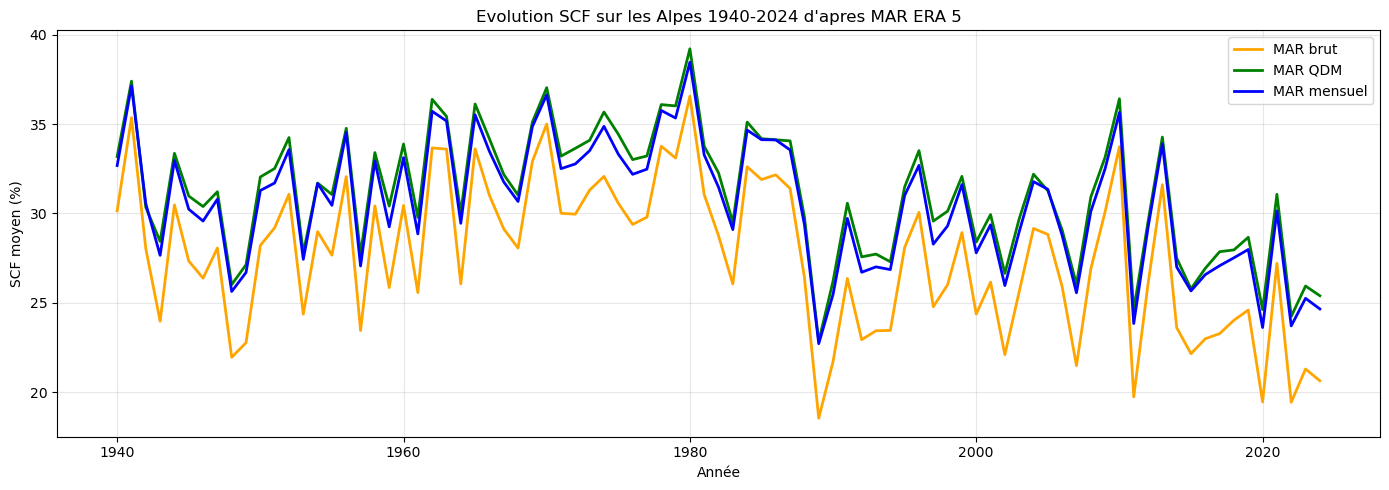

Tendance brut  : -9.51%
Tendance QDM   : -7.79%
Tendance corr  : -8.02%


In [16]:
# Plot tendances SCF
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_scf.year, df_scf.brut,  color='orange', label='MAR brut',    linewidth=2)
ax.plot(df_scf.year, df_scf.qdm,   color='green',  label='MAR QDM',     linewidth=2)
ax.plot(df_scf.year, df_scf.mensuel,  color='blue',   label='MAR mensuel', linewidth=2)
ax.set_ylabel('SCF moyen (%)')
ax.set_xlabel('Année')
ax.set_title("Evolution SCF sur les Alpes 1940-2024 d'apres MAR ERA 5")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/home/mougina/mes_analyses/correction_MAR/Evolution_SCF_moy_MAR_Corr.png', dpi=100)
plt.show()

print(f"Tendance brut  : {df_scf.brut.iloc[-1]  - df_scf.brut.iloc[0]:.2f}%")
print(f"Tendance QDM   : {df_scf.qdm.iloc[-1]   - df_scf.qdm.iloc[0]:.2f}%")
print(f"Tendance corr  : {df_scf.mensuel.iloc[-1]  - df_scf.mensuel.iloc[0]:.2f}%")



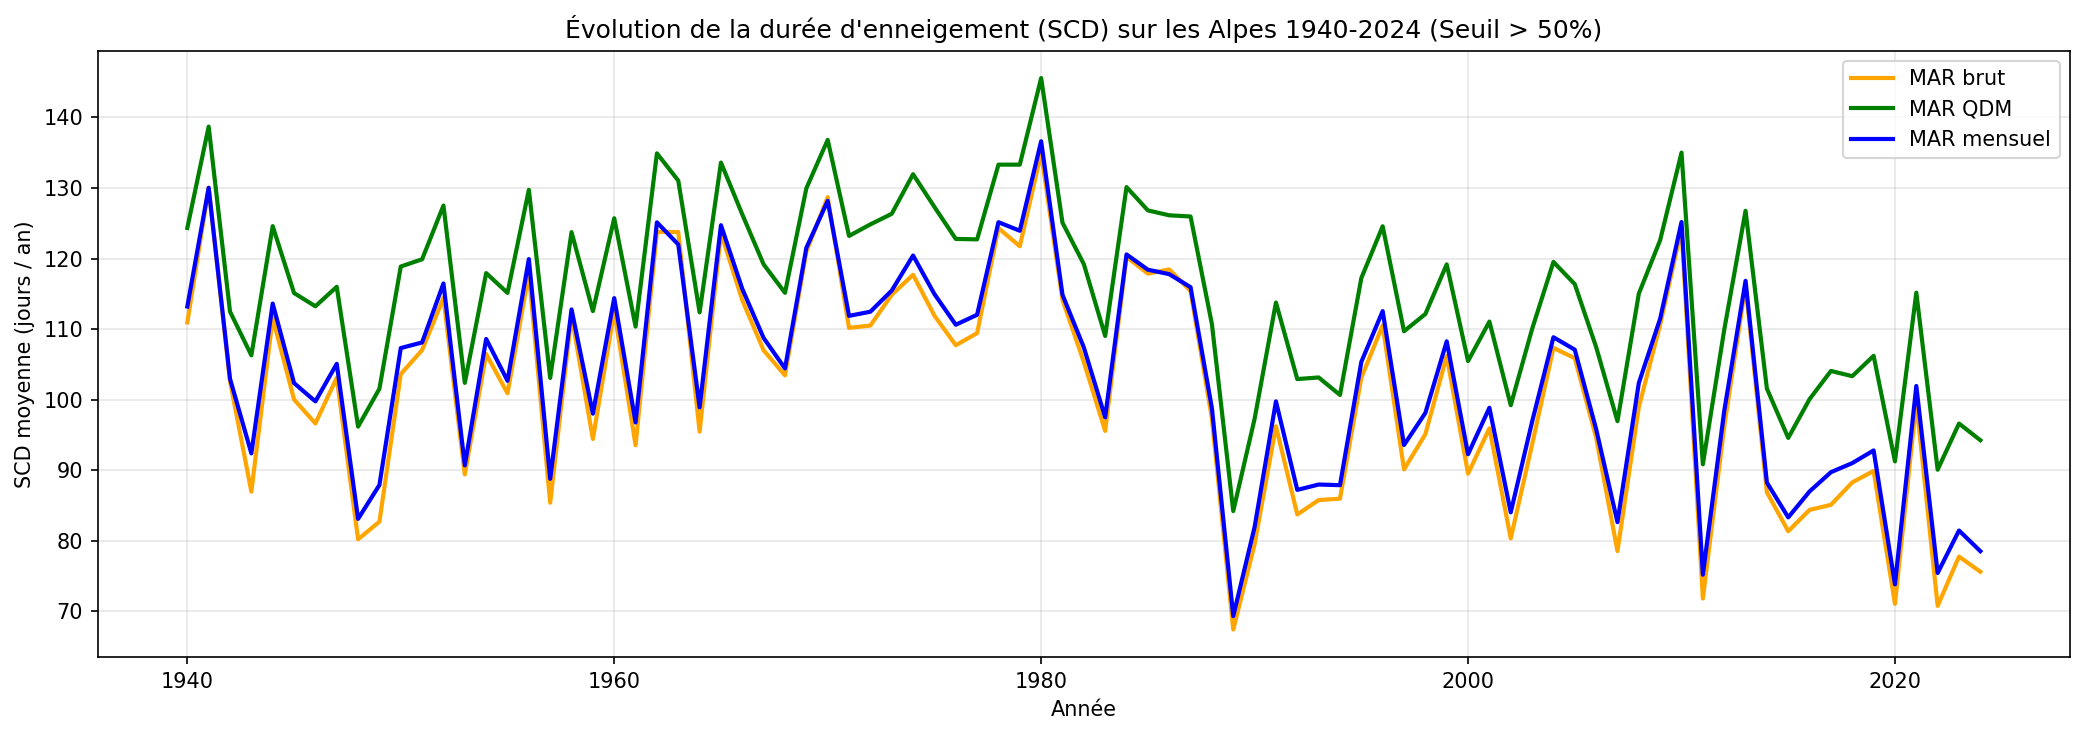

Tendance SCD brut    : -35.36 jours
Tendance SCD QDM     : -30.10 jours
Tendance SCD corr    : -34.69 jours


In [17]:

plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':       10,
    'axes.titlesize':  12,
    'figure.dpi':      150,
})

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_scf.year, df_scf.scd_brut,    color='orange', label='MAR brut',    linewidth=2)
ax.plot(df_scf.year, df_scf.scd_qdm,     color='green',  label='MAR QDM',     linewidth=2)
ax.plot(df_scf.year, df_scf.scd_mensuel, color='blue',   label='MAR mensuel', linewidth=2)
ax.set_ylabel('SCD moyenne (jours / an)')
ax.set_xlabel('Année')
ax.set_title("Évolution de la durée d'enneigement (SCD) sur les Alpes 1940-2024 (Seuil > 50%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/home/mougina/mes_analyses/correction_MAR/Evolution_SCD_moy_MAR_Corr.png', dpi=150)
plt.show()

print(f"Tendance SCD brut    : {df_scf.scd_brut.iloc[-1]    - df_scf.scd_brut.iloc[0]:.2f} jours")
print(f"Tendance SCD QDM     : {df_scf.scd_qdm.iloc[-1]     - df_scf.scd_qdm.iloc[0]:.2f} jours")
print(f"Tendance SCD corr    : {df_scf.scd_mensuel.iloc[-1] - df_scf.scd_mensuel.iloc[0]:.2f} jours")

## Ligne de neige 

In [41]:

months_per_year = 12
years_unique = np.unique(ligne_neige_qdm.time.dt.year.values)
n_years = len(years_unique)

monthly_ln_qdm = np.full((n_years, months_per_year), np.nan)
for iy, yr in enumerate(years_unique):
    for m in range(1, 13):
        vals = ligne_neige_qdm.sel(
            time=(ligne_neige_qdm.time.dt.year == yr) & 
                 (ligne_neige_qdm.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_qdm[iy, m-1] = float(vals.values)

monthly_ln_corr = np.full((n_years, months_per_year), np.nan)
for iy, yr in enumerate(years_unique):
    for m in range(1, 13):
        vals = ligne_neige_corr.sel(
            time=(ligne_neige_corr.time.dt.year == yr) & 
                 (ligne_neige_corr.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_corr[iy, m-1] = float(vals.values)


monthly_ln_brut = np.full((n_years, months_per_year), np.nan)
for iy, yr in enumerate(years_unique):
    for m in range(1, 13):
        vals = ligne_neige_brut.sel(
            time=(ligne_neige_brut.time.dt.year == yr) & 
                 (ligne_neige_brut.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_brut[iy, m-1] = float(vals.values)

In [43]:

slope_qdm = np.full(months_per_year, np.nan);   pvalue_qdm = np.full(months_per_year, np.nan)
slope_corr = np.full(months_per_year, np.nan); pvalue_corr = np.full(months_per_year, np.nan)
slope_brut = np.full(months_per_year, np.nan);  pvalue_brut = np.full(months_per_year, np.nan)

for imonth in range(months_per_year):

    mask_qdm = ~np.isnan(monthly_ln_qdm[:, imonth])
    if mask_qdm.sum() > 10:
        reg_qdm = stats.linregress(np.where(mask_qdm)[0], monthly_ln_qdm[mask_qdm, imonth])
        slope_qdm[imonth], pvalue_qdm[imonth] = reg_qdm.slope, reg_qdm.pvalue
        

    mask_corr = ~np.isnan(monthly_ln_corr[:, imonth])
    if mask_biais.sum() > 10:
        reg_corr = stats.linregress(np.where(mask_corr)[0], monthly_ln_corr[mask_corr, imonth])
        slope_corr[imonth], pvalue_corr[imonth] = reg_corr.slope, reg_corr.pvalue
        

    mask_brut = ~np.isnan(monthly_ln_brut[:, imonth])
    if mask_brut.sum() > 10:
        reg_brut = stats.linregress(np.where(mask_brut)[0], monthly_ln_brut[mask_brut, imonth])
        slope_brut[imonth], pvalue_brut[imonth] = reg_brut.slope, reg_brut.pvalue

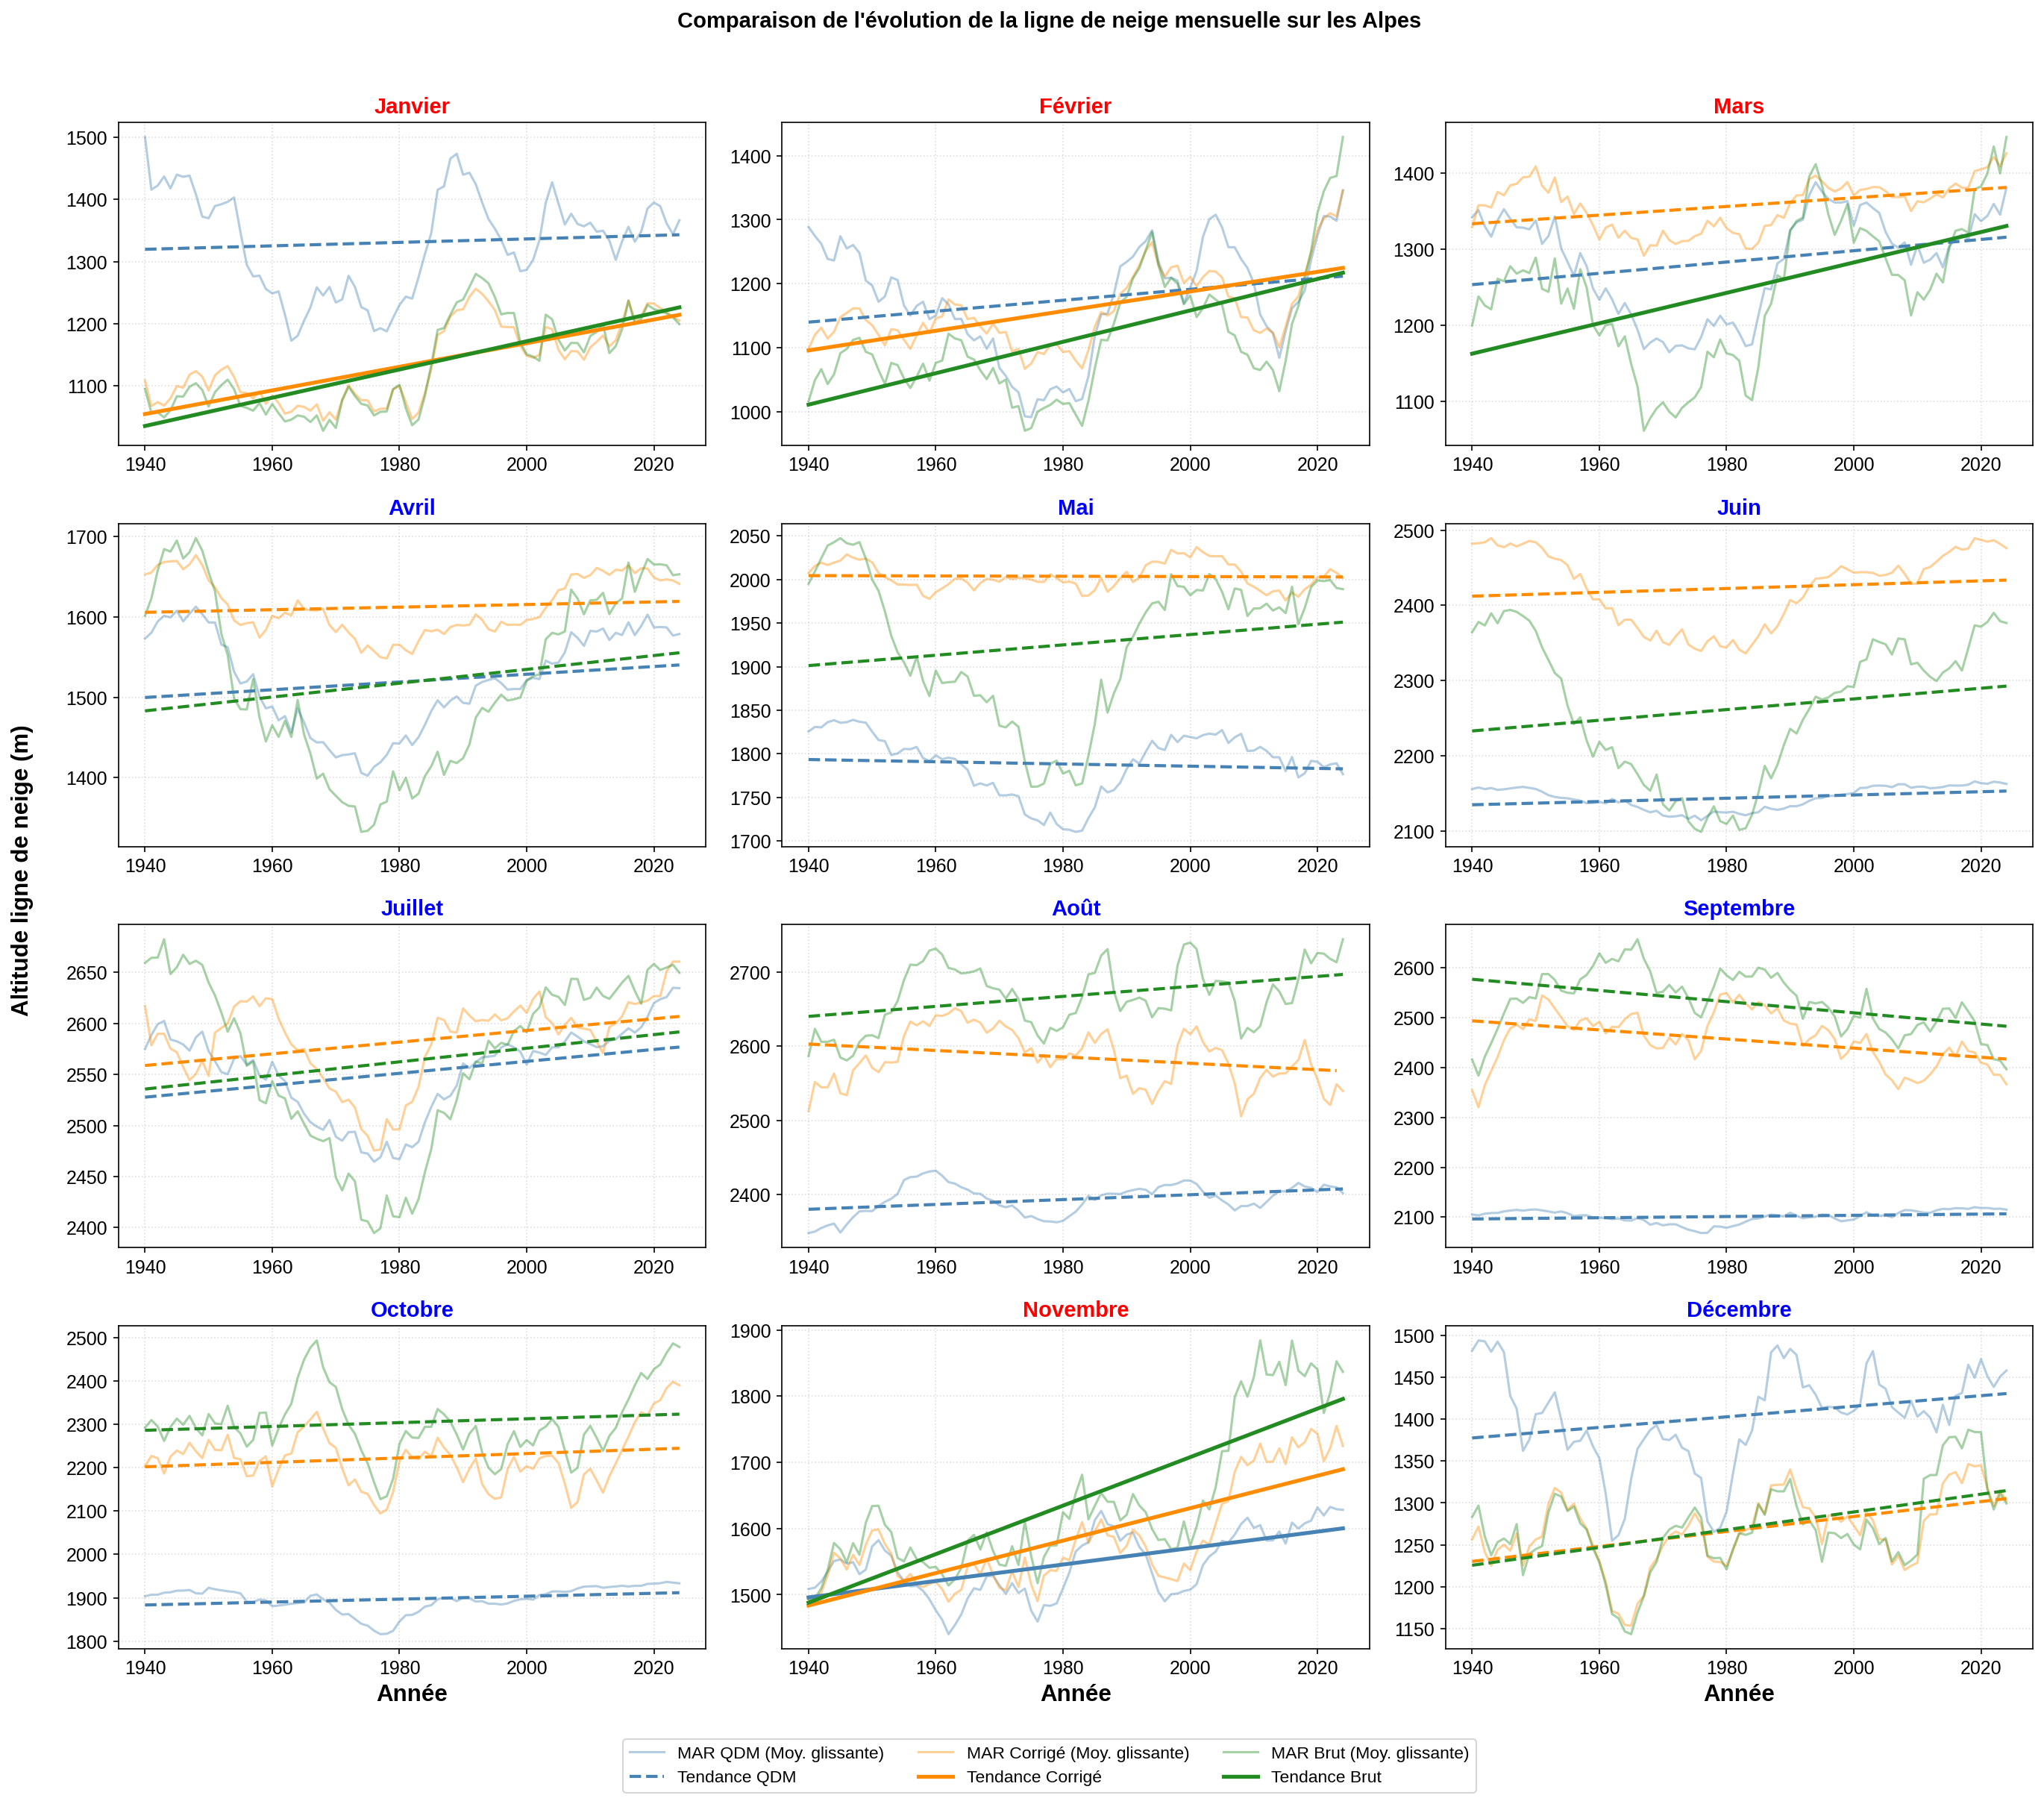

In [49]:

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'],
    'font.size': 14,
    'axes.titlesize': 14
})

mois_noms = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
             'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']


fig, axs = plt.subplots(4, 3, figsize=(18, 16), sharey=False)
axs_flat = axs.flatten()
c_qdm, c_corr, c_brut = 'steelblue', 'darkorange', 'forestgreen'

for i in range(months_per_year):
    ax = axs_flat[i]
    est_significatif = (pvalue_qdm[i] < 0.05) or (pvalue_corr[i] < 0.05) or (pvalue_brut[i] < 0.05)
    color_titre = 'red' if est_significatif else 'blue'
    ax.set_title(mois_noms[i], color=color_titre, weight='bold')
    lbl_qdm   = 'MAR QDM (Moy. glissante)' if i == 0 else None
    lbl_corr  = 'MAR Corrigé (Moy. glissante)' if i == 0 else None
    lbl_brut  = 'MAR Brut (Moy. glissante)' if i == 0 else None
    
    lbl_t_qdm   = 'Tendance QDM' if i == 0 else None
    lbl_t_corr  = 'Tendance Corrigé' if i == 0 else None
    lbl_t_brut  = 'Tendance Brut' if i == 0 else None
    roll_qdm = pd.Series(monthly_ln_qdm[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique, roll_qdm, color=c_qdm, linewidth=1.5, alpha=0.4, zorder=2, label=lbl_qdm)
    
    if not np.isnan(slope_qdm[i]):
        style_l = 'solid' if pvalue_qdm[i] < 0.05 else 'dashed'
        largeur_l = 2.5 if pvalue_qdm[i] < 0.05 else 2
        mask = ~np.isnan(monthly_ln_qdm[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_qdm[:, i]) - slope_qdm[i] * np.mean(x_reg)
        ax.plot(years_unique[mask], intercept_local + slope_qdm[i] * x_reg, 
                color=c_qdm, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_t_qdm)

    roll_corr = pd.Series(monthly_ln_corr[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique, roll_corr, color=c_corr, linewidth=1.5, alpha=0.4, zorder=2, label=lbl_corr)
    
    if not np.isnan(slope_corr[i]):
        style_l = 'solid' if pvalue_corr[i] < 0.05 else 'dashed'
        largeur_l = 2.5 if pvalue_corr[i] < 0.05 else 2
        mask = ~np.isnan(monthly_ln_corr[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_corr[:, i]) - slope_corr[i] * np.mean(x_reg)
        ax.plot(years_unique[mask], intercept_local + slope_corr[i] * x_reg, 
                color=c_corr, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_t_corr)

    roll_brut = pd.Series(monthly_ln_brut[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique, roll_brut, color=c_brut, linewidth=1.5, alpha=0.4, zorder=2, label=lbl_brut)
    
    if not np.isnan(slope_brut[i]):
        style_l = 'solid' if pvalue_brut[i] < 0.05 else 'dashed'
        largeur_l = 2.5 if pvalue_brut[i] < 0.05 else 2
        mask = ~np.isnan(monthly_ln_brut[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_brut[:, i]) - slope_brut[i] * np.mean(x_reg)
        ax.plot(years_unique[mask], intercept_local + slope_brut[i] * x_reg, 
                color=c_brut, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_t_brut)

    ax.grid(True, linestyle=':', alpha=0.4)
    ax.tick_params(labelsize=12)

for ax in axs_flat[9:12]:
    ax.set_xlabel('Année', fontsize=15, fontweight='bold')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=3, frameon=True, fontsize=11)

fig.text(-0.01, 0.53, 'Altitude ligne de neige (m)', va='center', ha='center', rotation='vertical', fontsize=15, weight='bold')
plt.suptitle('Comparaison de l\'évolution de la ligne de neige mensuelle sur les Alpes', size=14, weight='bold', y=1.01)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('/home/mougina/mes_analyses/correction_MAR/comparaison_corrections_ligne_neige.png', dpi=200, bbox_inches='tight')
plt.show()

In [20]:
print("LON min/max :", float(ds_grid['LON'].min()), float(ds_grid['LON'].max()))
print("LAT min/max :", float(ds_grid['LAT'].min()), float(ds_grid['LAT'].max()))

LON min/max : 0.5260846018791199 19.775012969970703
LAT min/max : 41.29502487182617 49.69010543823242
